In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [3]:
import numpy as np
import pandas as pd # get_dummies
from tensorflow.keras.models import Sequential, save_model, load_model
# from tensorflow.keras.datasets import mnist # mnist 데이터 셋 => 훈련셋과 테스트셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.layers import Dense, Input, Dropout
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split # 데이터 분리
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

- Red Wine 등급 예측
1. 데이터 셋 확보
    csv -> 

# 1. 데이터 확보 및 전처리

In [6]:
df = pd.read_csv('data/winequality-red.csv',sep=';')

In [7]:
df.info() # 결측치 없고 데이터 전부 숫자형

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [17]:
# 종속변수 데이터 분포 체크
df.iloc[:,-1:].value_counts() # 5 681, 6 638, 7 199, 4 53, 8 18, 3 10

quality
5          681
6          638
7          199
4           53
8           18
3           10
dtype: int64

In [14]:
X_data = df.iloc[:,:-1].values
y_data = df.iloc[:,-1].values

In [22]:
# 독립변수 스케일 조정
X_scaler = MinMaxScaler()
scaled_X_data = X_scaler.fit_transform(X_data)
scaled_X_data

array([[0.24778761, 0.39726027, 0.        , ..., 0.60629921, 0.13772455,
        0.15384615],
       [0.28318584, 0.52054795, 0.        , ..., 0.36220472, 0.20958084,
        0.21538462],
       [0.28318584, 0.43835616, 0.04      , ..., 0.40944882, 0.19161677,
        0.21538462],
       ...,
       [0.15044248, 0.26712329, 0.13      , ..., 0.53543307, 0.25149701,
        0.4       ],
       [0.11504425, 0.35958904, 0.12      , ..., 0.65354331, 0.22754491,
        0.27692308],
       [0.12389381, 0.13013699, 0.47      , ..., 0.51181102, 0.19760479,
        0.4       ]])

In [28]:
# 종속변수 원핫 인코딩
onehot_y_data = to_categorical(y_data)
onehot_y_data.shape # => 1599, 9 : 최댓값 8에 맞춰서..

(1599, 9)

In [89]:
# 데이터 셋 분할 : 훈련데이터 - 시험데이터
X_train, X_test, Y_train, Y_test = train_test_split(scaled_X_data,onehot_y_data, test_size=0.05,stratify=onehot_y_data)
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((1519, 11), (1519, 9), (80, 11), (80, 9))

In [90]:
pd.DataFrame(Y_train).value_counts() # 층화 분류

0    1    2    3    4    5    6    7    8  
0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0    647
                         0.0  1.0  0.0  0.0    606
                              0.0  1.0  0.0    189
                    1.0  0.0  0.0  0.0  0.0     50
                    0.0  0.0  0.0  0.0  1.0     17
               1.0  0.0  0.0  0.0  0.0  0.0     10
dtype: int64

# 2. 모델 구성 및 생성

In [169]:
model = Sequential()
model.add(Input(shape=(11,)))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
from tensorflow.keras.layers import LeakyReLU
model.add(Dense(128))
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dense(9, activation='softmax'))
model.summary()

Model: "sequential_22"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_108 (Dense)           (None, 128)               1536      
                                                                 
 dropout_35 (Dropout)        (None, 128)               0         
                                                                 
 dense_109 (Dense)           (None, 64)                8256      
                                                                 
 dense_110 (Dense)           (None, 128)               8320      
                                                                 
 leaky_re_lu_6 (LeakyReLU)   (None, 128)               0         
                                                                 
 dropout_36 (Dropout)        (None, 128)               0         
                                                                 
 dense_111 (Dense)           (None, 32)              

# 3. 모델 학습과정 설정

In [170]:
from tensorflow.keras.optimizers import Adam
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.0005),
              metrics=['accuracy'])

# 4. 모델 학습

In [171]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import os
model_save_folder = './wine/'
if not os.path.exists(model_save_folder) :
    os.mkdir(model_save_folder)
file = model_save_folder + 'mnist-{epoch:03d}-val{val_accuracy:.4f}.h5'

checkpoint=ModelCheckpoint(monitor = 'val_accuracy',save_best_only=True,filepath=file)

earlystop = EarlyStopping(patience=20,restore_best_weights=True)

hist = model.fit(X_train,Y_train, epochs=10000, batch_size=32,
         validation_split=0.15, callbacks=[checkpoint,earlystop])

Epoch 1/10000
41/41 [==============================] - 1s 9ms/step - loss: 1.8720 - accuracy: 0.3780 - val_loss: 1.3661 - val_accuracy: 0.5044
Epoch 2/10000
41/41 [==============================] - 0s 4ms/step - loss: 1.2696 - accuracy: 0.4338 - val_loss: 1.2282 - val_accuracy: 0.4781
Epoch 3/10000
41/41 [==============================] - 0s 4ms/step - loss: 1.2010 - accuracy: 0.4609 - val_loss: 1.1509 - val_accuracy: 0.5482
Epoch 4/10000
41/41 [==============================] - 0s 4ms/step - loss: 1.1085 - accuracy: 0.5244 - val_loss: 1.0904 - val_accuracy: 0.5789
Epoch 5/10000
41/41 [==============================] - 0s 4ms/step - loss: 1.0627 - accuracy: 0.5407 - val_loss: 1.0615 - val_accuracy: 0.5789
Epoch 6/10000
41/41 [==============================] - 0s 3ms/step - loss: 1.0527 - accuracy: 0.5585 - val_loss: 1.0403 - val_accuracy: 0.5789
Epoch 7/10000
41/41 [==============================] - 0s 4ms/step - loss: 1.0347 - accuracy: 0.5670 - val_loss: 1.0360 - val_accuracy: 0.6009

Epoch 58/10000
41/41 [==============================] - 0s 5ms/step - loss: 0.9036 - accuracy: 0.5957 - val_loss: 0.9355 - val_accuracy: 0.6228
Epoch 59/10000
41/41 [==============================] - 0s 4ms/step - loss: 0.9030 - accuracy: 0.6328 - val_loss: 0.9207 - val_accuracy: 0.6140
Epoch 60/10000
41/41 [==============================] - 0s 4ms/step - loss: 0.8860 - accuracy: 0.6204 - val_loss: 0.9172 - val_accuracy: 0.6228
Epoch 61/10000
41/41 [==============================] - 0s 3ms/step - loss: 0.8897 - accuracy: 0.6096 - val_loss: 0.9157 - val_accuracy: 0.6184
Epoch 62/10000
41/41 [==============================] - 0s 3ms/step - loss: 0.8820 - accuracy: 0.6235 - val_loss: 0.9163 - val_accuracy: 0.6272
Epoch 63/10000
41/41 [==============================] - 0s 3ms/step - loss: 0.8803 - accuracy: 0.6127 - val_loss: 0.9104 - val_accuracy: 0.6404
Epoch 64/10000
41/41 [==============================] - 0s 3ms/step - loss: 0.9042 - accuracy: 0.6166 - val_loss: 0.9141 - val_accuracy:

# 5. 모델 학습과정 확인하기

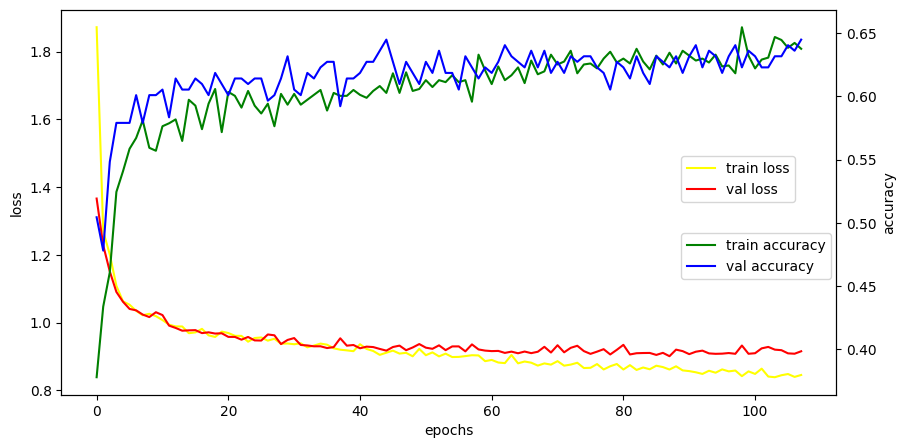

In [172]:
# hist.history.keys() # loss accuracy val_loss val_accuracy
fig, loss_ax = plt.subplots(figsize = (10,5))
loss_ax.plot(hist.history.get('loss'), color='yellow', label='train loss')
loss_ax.plot(hist.history.get('val_loss'), color='red', label='val loss')
loss_ax.legend(loc=(0.8,0.5))
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history.get('accuracy'), color='green', label='train accuracy')
acc_ax.plot(hist.history.get('val_accuracy'), color='blue', label='val accuracy')
acc_ax.legend(loc=(0.8,0.3))
acc_ax.set_ylabel('accuracy')
plt.show()

# 6. 모델 평가하기

In [173]:
# 교차맵
y_hat = model.predict(X_test).argmax(axis=1)

3/3 [==============================] - 0s 3ms/step


In [174]:
pd.crosstab(Y_test.argmax(axis=1),y_hat, rownames=['실제값'],colnames=['예측값'])
# Y_test.argmax(axis=1)[Y_test.argmax(axis=1)==y_hat].shape # 104개 정답
# Y_test.argmax(axis=1)[Y_test.argmax(axis=1)!=y_hat].shape # 56개 오답

예측값,5,6,7
실제값,,,
4,3,0,0
5,30,4,0
6,15,17,0
7,0,6,4
8,0,0,1


In [175]:
# evaluate
loss_and_accuracy = model.evaluate(X_test,Y_test)
print('loss :',loss_and_accuracy[0])
print('accuracy :',round((loss_and_accuracy[1]*100),2),'%')

3/3 [==============================] - 0s 3ms/step - loss: 0.9627 - accuracy: 0.6375
loss : 0.9627225995063782
accuracy : 63.75 %


# 7. 모델 저장하기

In [103]:
model.save('model/wine.h5')

# 8. 모델 로드하기

In [102]:
model2 = load_model('wine/mnist-063-val0.6551.h5')

In [100]:
model2.predict(np.array([X_test[0]])).argmax(axis=1)

1/1 [==============================] - 0s 96ms/step


array([5], dtype=int64)

In [101]:
Y_test[0].argmax()

5

In [123]:
model.evaluate(scaled_X_data,onehot_y_data)
# scaled_X_data
# onehot_y_data

50/50 [==============================] - 0s 4ms/step - loss: 0.9339 - accuracy: 0.6079


[0.9339366555213928, 0.6078799366950989]

# 모델 장난감

In [130]:

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import os
model_save_folder = './wine/'
if not os.path.exists(model_save_folder) :
    os.mkdir(model_save_folder)
file = model_save_folder + 'mnist-{epoch:03d}-val{val_accuracy:.4f}.h5'

checkpoint=ModelCheckpoint(monitor = 'val_accuracy',save_best_only=True,filepath=file)

earlystop = EarlyStopping(patience=10,restore_best_weights=True)

hist = model.fit(scaled_X_data,onehot_y_data, epochs=10000,
         validation_split=0.01, callbacks=[checkpoint,earlystop])

Epoch 1/10000
50/50 [==============================] - 1s 9ms/step - loss: 1.4164 - accuracy: 0.4346 - val_loss: 0.9305 - val_accuracy: 0.3125
Epoch 2/10000
50/50 [==============================] - 0s 5ms/step - loss: 1.0855 - accuracy: 0.5483 - val_loss: 0.6504 - val_accuracy: 0.7500
Epoch 3/10000
50/50 [==============================] - 0s 5ms/step - loss: 1.0315 - accuracy: 0.5711 - val_loss: 0.6712 - val_accuracy: 0.8125
Epoch 4/10000
50/50 [==============================] - 0s 5ms/step - loss: 1.0096 - accuracy: 0.5761 - val_loss: 0.6557 - val_accuracy: 0.8750
Epoch 5/10000
50/50 [==============================] - 0s 4ms/step - loss: 0.9953 - accuracy: 0.5685 - val_loss: 0.7896 - val_accuracy: 0.6875
Epoch 6/10000
50/50 [==============================] - 0s 5ms/step - loss: 0.9939 - accuracy: 0.5793 - val_loss: 0.6057 - val_accuracy: 0.8125
Epoch 7/10000
50/50 [==============================] - 0s 5ms/step - loss: 0.9717 - accuracy: 0.5913 - val_loss: 0.6217 - val_accuracy: 0.8125

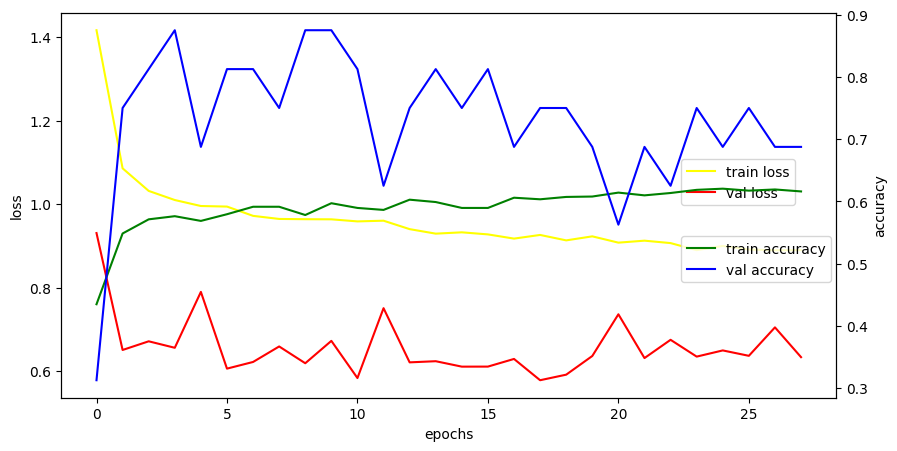

In [131]:
# hist.history.keys() # loss accuracy val_loss val_accuracy
fig, loss_ax = plt.subplots(figsize = (10,5))
loss_ax.plot(hist.history.get('loss'), color='yellow', label='train loss')
loss_ax.plot(hist.history.get('val_loss'), color='red', label='val loss')
loss_ax.legend(loc=(0.8,0.5))
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history.get('accuracy'), color='green', label='train accuracy')
acc_ax.plot(hist.history.get('val_accuracy'), color='blue', label='val accuracy')
acc_ax.legend(loc=(0.8,0.3))
acc_ax.set_ylabel('accuracy')
plt.show()

In [132]:
model_set = load_model('wine/mnist-004-val0.8750.h5')

In [133]:
model_set.evaluate(X_test,Y_test)

3/3 [==============================] - 0s 4ms/step - loss: 0.9758 - accuracy: 0.6000


[0.9757979512214661, 0.6000000238418579]